/var/folders/7z/npwd4mkj50g10rrf3zlkgr4m0000gn/T/ipykernel_99583/443230238.py:30: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(d[gcol]):


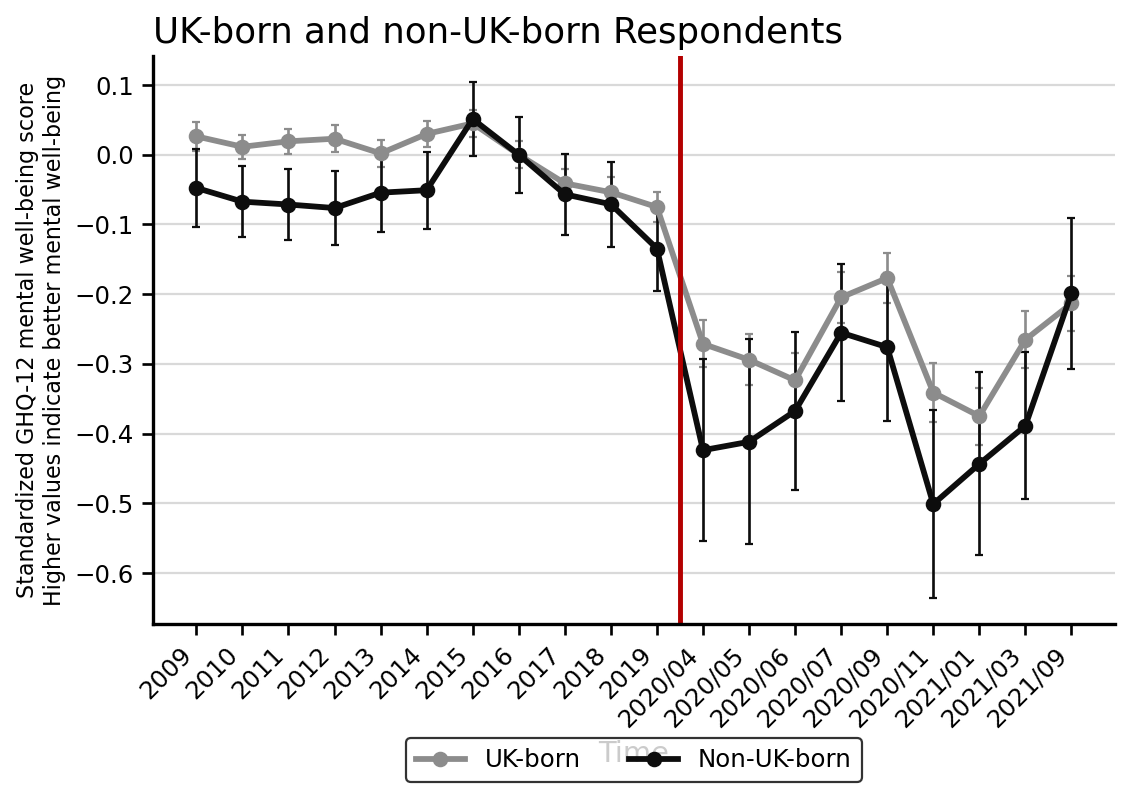

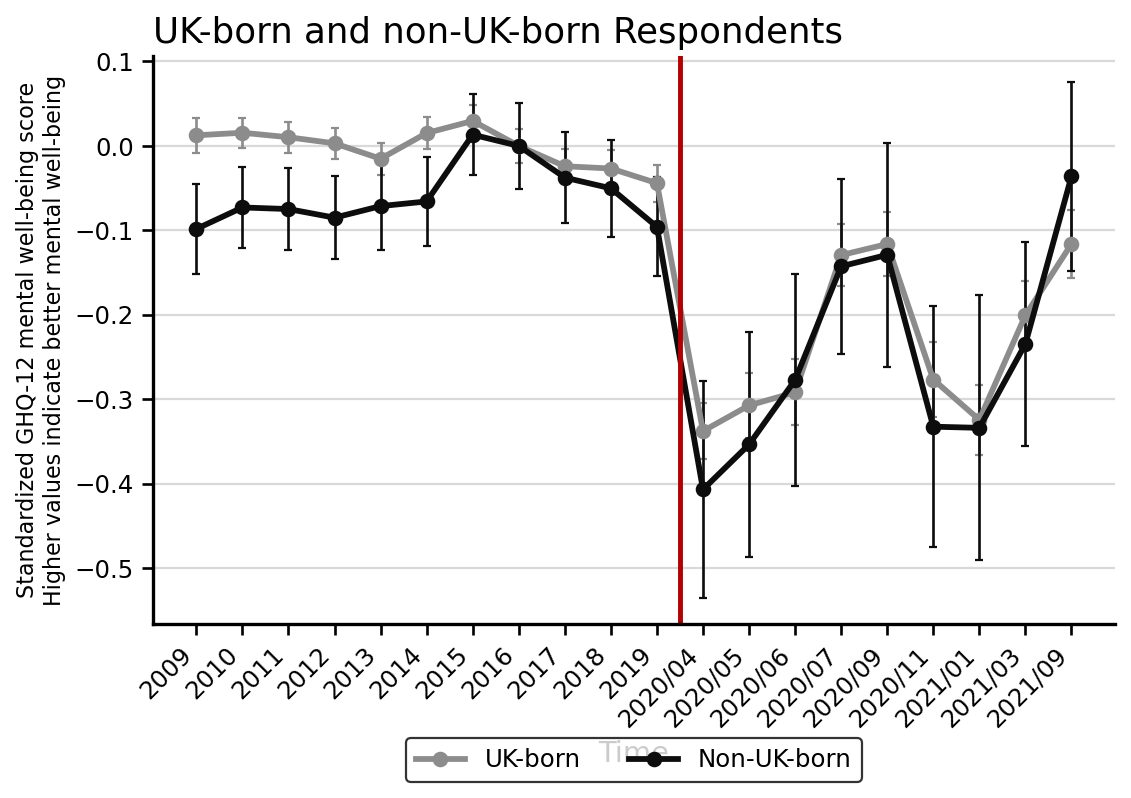

/var/folders/7z/npwd4mkj50g10rrf3zlkgr4m0000gn/T/ipykernel_99583/443230238.py:30: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(d[gcol]):


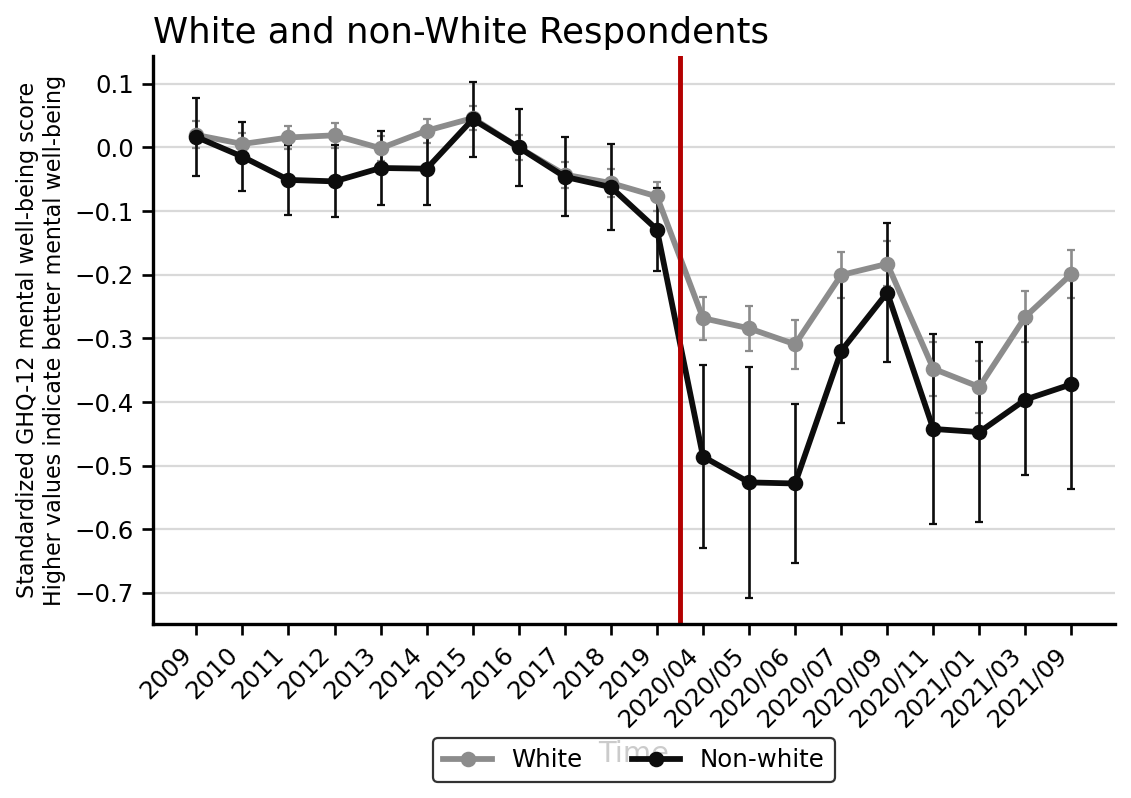

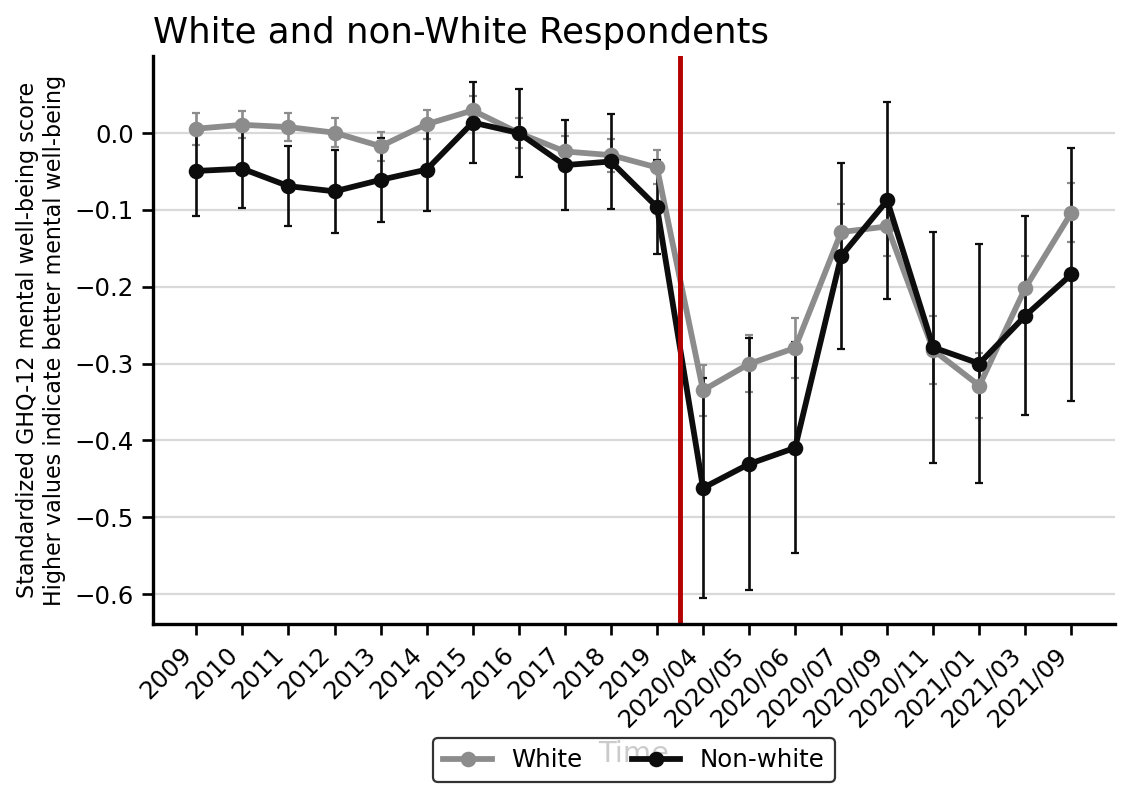

/var/folders/7z/npwd4mkj50g10rrf3zlkgr4m0000gn/T/ipykernel_99583/443230238.py:30: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(d[gcol]):


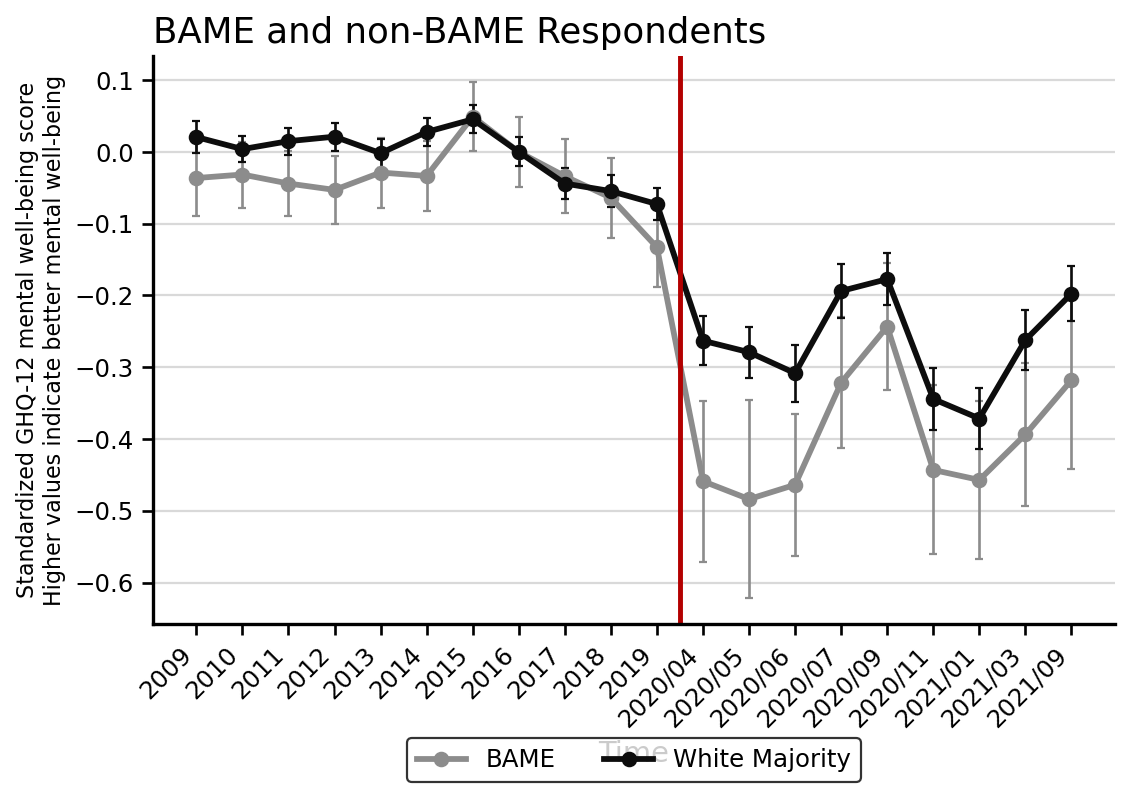

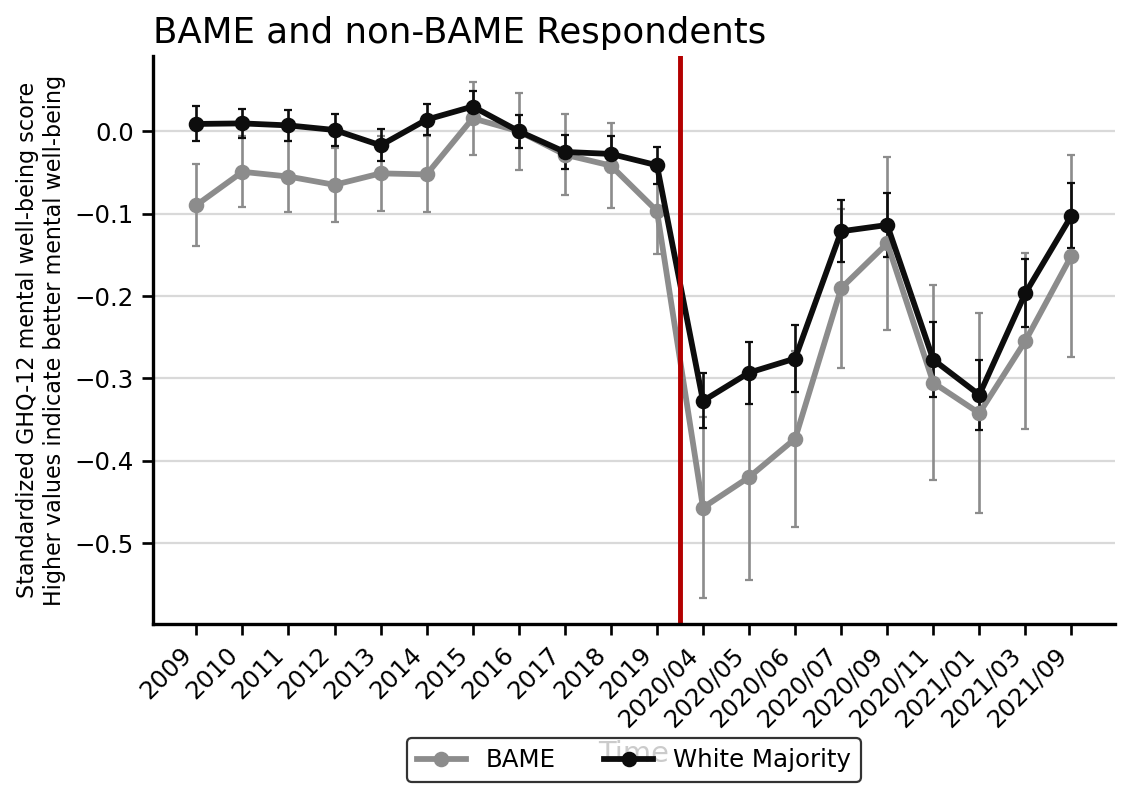

/var/folders/7z/npwd4mkj50g10rrf3zlkgr4m0000gn/T/ipykernel_99583/443230238.py:30: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(d[gcol]):


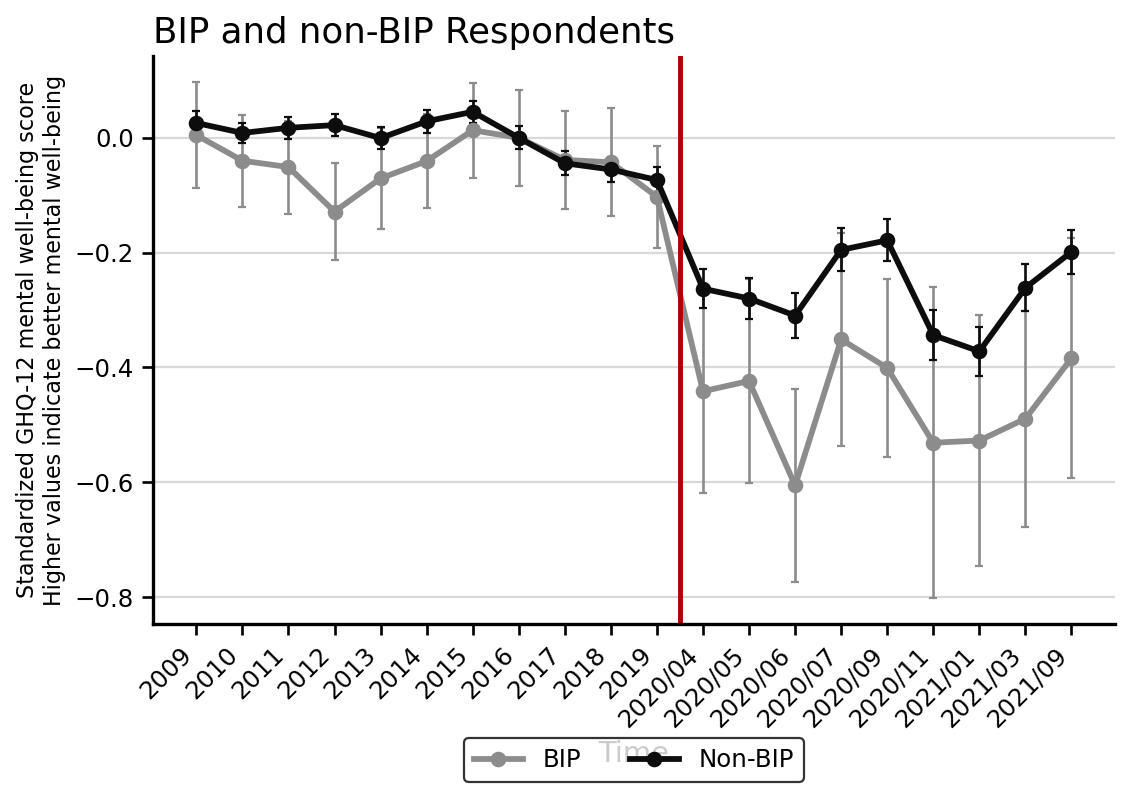

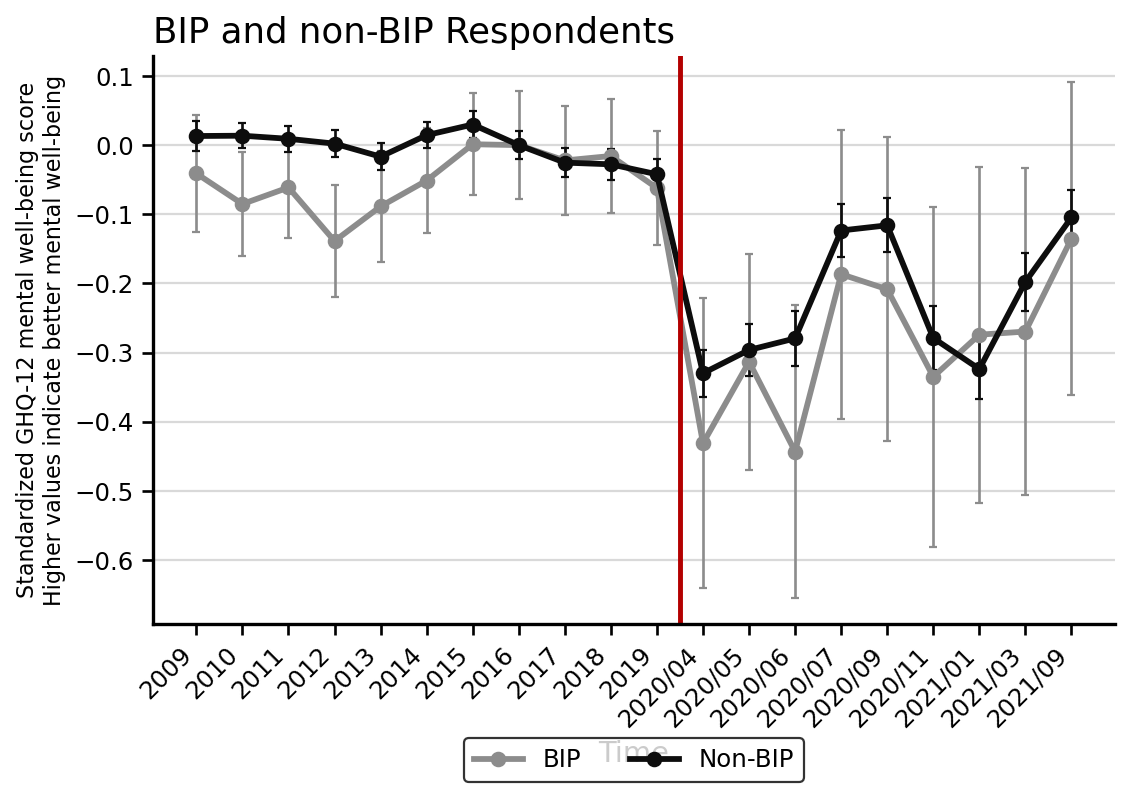

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

out_dir = r"/Users/lishixue/Documents/Master thesis/Statafile/Thesis2026/out/Descriptive trends"

order = [str(y) for y in range(2009, 2020)] + \
        [f"2020/{m:02d}" for m in [4,5,6,7,9,11]] + \
        [f"2021/{m:02d}" for m in [1,3,9]]

plt.rcParams.update({
    "figure.dpi": 160,
    "savefig.dpi": 300,
    "font.size": 11
})

def prep_time_and_group(d, gcol):
    d = d.copy()

    covid_map = {
        "CA": "2020/04", "CB": "2020/05", "CC": "2020/06", "CD": "2020/07",
        "CE": "2020/09", "CF": "2020/11", "CG": "2021/01", "CH": "2021/03", "CI": "2021/09"
    }

    d["time_label"] = d["time_label"].astype(str).str.strip().str.upper()
    d["time_label"] = d["time_label"].replace(covid_map)
    d["time_label"] = pd.Categorical(d["time_label"], categories=order, ordered=True)

    if pd.api.types.is_categorical_dtype(d[gcol]):
        d[gcol] = d[gcol].astype(str)

    d[gcol] = pd.to_numeric(d[gcol], errors="coerce")
    return d


def index_to_base(d, gcol, mean_col, se_col, base="2016"):
    """
    each mean uses base year 0 recode
    sqrt(se_t^2 + se_base^2) approximates index SE。
    """
    d = d.copy()

    base_df = d.loc[d["time_label"].astype(str) == base, [gcol, mean_col, se_col]].dropna()

    if base_df.empty:
        print(f"[WARN] No base-year observations found for {mean_col} at base={base}")
        d[mean_col + "_idx"] = np.nan
        d[se_col + "_idx"] = np.nan
        return d

    base_means = base_df.set_index(gcol)[mean_col].to_dict()
    base_ses   = base_df.set_index(gcol)[se_col].to_dict()

    missing_base = set(d[gcol].dropna().unique()) - set(base_means.keys())
    if missing_base:
        print(f"[WARN] {mean_col}: base year {base} missing for groups: {missing_base}")

    d[mean_col + "_idx"] = d.apply(
        lambda r: r[mean_col] - base_means.get(r[gcol], np.nan),
        axis=1
    )

    d[se_col + "_idx"] = d.apply(
        lambda r: np.sqrt(r[se_col]**2 + base_ses.get(r[gcol], np.nan)**2)
        if pd.notna(r[se_col]) and pd.notna(base_ses.get(r[gcol], np.nan))
        else np.nan,
        axis=1
    )

    return d


def plot_two_groups_eventstyle_CI_midline(
    d, gcol, labels, mean_idx_col, se_idx_col,
    title, fname, out_dir,
    left_label="2019", right_label="2020/04",
    event_text=None,
    ci_mult=1.96
):
    cats = d["time_label"].cat.categories.astype(str).tolist()
    xmap = {c: i for i, c in enumerate(cats)}

    fig, ax = plt.subplots(figsize=(7.2, 5.2))

    ax.set_axisbelow(True)
    ax.yaxis.grid(True, color="0.85", linewidth=1)
    ax.xaxis.grid(False)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_linewidth(1.5)
    ax.spines["bottom"].set_linewidth(1.5)
    ax.tick_params(axis="both", which="both", direction="out", length=5, width=1.2)

    keys = list(labels.keys())
    style = {
        keys[0]: dict(color="0.55"),
        keys[1]: dict(color="0.05"),
    }

    for gval, lab in labels.items():
        sub = d[d[gcol] == gval].copy()
        sub["x"] = sub["time_label"].astype(str).map(xmap)
        sub = sub.dropna(subset=["x", mean_idx_col, se_idx_col]).sort_values("x")

        if sub.empty:
            continue

        ax.errorbar(
            sub["x"], sub[mean_idx_col],
            yerr=ci_mult * sub[se_idx_col],
            fmt="none",
            ecolor=style[gval]["color"],
            elinewidth=1.2,
            capsize=2,
            alpha=1.0,
            zorder=1
        )

        ax.plot(
            sub["x"], sub[mean_idx_col],
            marker="o", linewidth=2.6, markersize=6,
            color=style[gval]["color"],
            markerfacecolor=style[gval]["color"],
            markeredgecolor=style[gval]["color"],
            label=lab,
            zorder=2
        )

    if left_label in xmap and right_label in xmap:
        xv = (xmap[left_label] + xmap[right_label]) / 2.0
        ax.axvline(x=xv, color="#b30000", linewidth=2.2)
        if event_text:
            ymin, ymax = ax.get_ylim()
            ax.text(
                xv + 0.3, ymin + 0.92*(ymax - ymin), event_text,
                ha="left", va="top", fontsize=12
            )

    ax.set_xticks(range(len(cats)))
    ax.set_xticklabels(cats, rotation=45, ha="right")

    ax.set_title(title, fontsize=16, loc="left")
    ax.set_xlabel("Time", fontsize=13)
    ax.set_ylabel("Standardized GHQ-12 mental well-being score\nHigher values indicate better mental well-being", fontsize=10)

    leg = ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.18), ncol=2, frameon=True)
    leg.get_frame().set_edgecolor("black")
    leg.get_frame().set_linewidth(1.0)
    leg.get_frame().set_facecolor("white")

    fig.tight_layout()
    fig.savefig(os.path.join(out_dir, fname), bbox_inches="tight")
    plt.show()


specs = [
    ("GHQaverage_UKborn.dta", "ukborn_flag", {1: "UK-born", 0: "Non-UK-born"}, "UK-born"),
    ("GHQaverage_White_NonWhite.dta", "white", {1: "White", 0: "Non-white"}, "White"),
    ("GHQaverage_BAME_NonBAME.dta", "bame", {1: "BAME", 0: "Non-BAME"}, "BAME"),
    ("GHQaverage_BIP_NonBIP.dta", "bip", {1: "BIP", 0: "Non-BIP"}, "BIP"),
]

for fn, gcol, labs, tag in specs:
    d = pd.read_stata(os.path.join(out_dir, fn), convert_categoricals=False)
    d = prep_time_and_group(d, gcol)

    d1 = index_to_base(d, gcol, "mean_likert", "se_likert", base="2016")
    plot_two_groups_eventstyle_CI_midline(
        d1, gcol, labs,
        mean_idx_col="mean_likert_idx",
        se_idx_col="se_likert_idx",
        title=f"{tag} and non-{tag} Respondents",
        fname=f"1{tag}_likert_index2016_CI_midline.png",
        out_dir=out_dir,
        left_label="2019",
        right_label="2020/04",
        event_text=None,
        ci_mult=1.96
    )

    d2 = index_to_base(d, gcol, "mean_case", "se_case", base="2016")
    plot_two_groups_eventstyle_CI_midline(
        d2, gcol, labs,
        mean_idx_col="mean_case_idx",
        se_idx_col="se_case_idx",
        title=f"{tag} and non-{tag} Respondents",
        fname=f"1{tag}_case_index2016_CI_midline.png",
        out_dir=out_dir,
        left_label="2019",
        right_label="2020/04",
        event_text=None,
        ci_mult=1.96
    )